# Exploratory Analysis
# Mushroom Observations

Visual sanity-checks on `mushroom.csv` (produced by [`01_data_preprocessing.ipynb`](01_data_preprocessing.ipynb)) before training the classifier in [`03_model_training_vgg19.ipynb`](03_model_training_vgg19.ipynb): where the observations are, how balanced the edibility and species labels are, and what the images actually look like.

In [2]:
import pandas as pd

df = pd.read_csv("../Data/mushroom.csv")

df.sample(5)

,Unnamed: 0,id,latitude,longitude,observed_on,place_guess,place_country_name,species_guess,scientific_name,common_name,image_filename,description,edibility,new_description
1874,2196,16346926,37.690100,-108.452000,2016-09-20,"Delores Co., Colorado, USA",United States,Salty Mushroom,Agaricus bernardii,Agaric des prés salés,img_2196.jpg,NaN,edible,"Edible, often salty-tasting mushroom, grows in..."
944,1115,8081714,-35.431319,173.459456,2016-09-22,"Oue 0473, New Zealand",New Zealand,Ear fungus,Auricularia cornea,Champignon noir,img_1115.jpg,NaN,edible,"Edible jelly fungus, dark brown, often called ..."
2431,2863,19714996,37.924274,-122.042862,2019-01-17,"638 Via Appia, Walnut Creek, CA, US",United States,Fairy Ring Marasmius,Marasmius oreades,Marasme des oréades,img_2863.jpg,NaN,edible,"Edible 'fairy ring mushroom,' small, grows in ..."
1663,1953,13915853,19.312753,-99.698105,2018-06-28,"Toluca, Méx., México",Mexico,Champiñón,Agaricus campestris,Agaric champêtre,img_1953.jpg,NaN,edible,"Edible field mushroom, white cap, common in gr..."
1146,1331,8844251,37.741600,-122.209953,2017-11-17,"Martin Luther King Jr. Regional Shoreline, Oak...",United States,Yellow Stainer,Agaricus xanthodermus,Agaric jaunissant,img_1331.jpg,Found in a hole in the ground .. animal tunnel,poisonous,"Poisonous yellow-staining mushroom, often mist..."


## Geographic distribution

Observation locations on a world map, colored by `edibility`, a first check that the dataset isn't concentrated in one region.

In [3]:
import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat='latitude',
    lon='longitude',
    hover_name='scientific_name',
    color="edibility",
    zoom=2
)

fig.update_layout(
    mapbox_style='open-street-map',
    margin={"r":0,"t":0,"l":0,"b":0}
)

fig.show()

C:\Users\souri\AppData\Local\Temp\ipykernel_31756\3127847244.py:3: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## Edibility balance

Count of observations per edibility class. This matters for training: a skewed distribution (few `poisonous`/`inedible` examples) is why the model training notebook later applies class weighting and boosts recall on non-edible species.

In [4]:
fig = px.bar(
    df["edibility"].value_counts(),
    labels={"index": "edibility", "value": "count"}
)

fig.show()

## Country distribution

Where observations were submitted from, as a secondary geography check.

In [5]:
fig = px.bar(
    df["place_country_name"].value_counts()
)

fig.show()

## Species class balance

Observation count per species, the long tail here (down to a handful of observations for some species) is what motivates the at least 50 observations cutoff applied in step 6 of the preprocessing notebook.

In [6]:
fig = px.bar(
    df["scientific_name"].value_counts()
)

fig.show()

print(df["scientific_name"].value_counts())

scientific_name
Agaricus xanthodermus    1112
Auricularia cornea        698
Marasmius oreades         676
Agaricus campestris       565
Agaricus augustus         536
Agaricus bitorquis        121
Agaricus bernardii        116
Agaricus arvensis          95
Agaricus                   52
Name: count, dtype: int64


## Sample images

A random grid of images with their species label, to visually confirm the image–label pairing is correct before training.

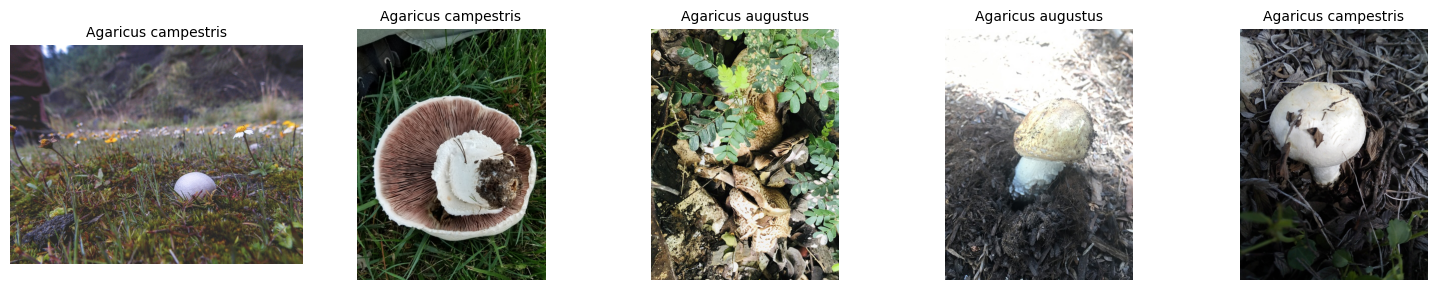

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = "../Data/images/"

sample_df = df.sample(5)

# Number of images to display
n = 5
sample_df = df.sample(n)

plt.figure(figsize=(15,3))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = mpimg.imread(os.path.join(folder, row['image_filename']))
    plt.subplot(1, n, i+1)
    plt.imshow(img)
    plt.title(f"{row['scientific_name']}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()